# 07 — Correlaciones entre variables dependientes

Este notebook analiza la **estructura de correlaciones y dependencias** entre las 4 VD normalizadas por minuto, explorando si las dimensiones técnica y física del rendimiento se mueven juntas o de forma independiente, y si esa estructura relacional cambia según el **tipo de tarea** y el **grupo de edad**.

**Objetivos:**
- Cuantificar las correlaciones globales (Pearson y Spearman) entre las 4 VD, prestando especial atención a la inflación de ceros en Golpeos/min y HID/min.
- Visualizar las relaciones bivariantes mediante scatterplots y matrices de dispersión.
- Evaluar si las correlaciones cambian según los niveles de las 3 VI de tarea (Formato_del_Juego, Polaridad, Equilibrio).
- Analizar la estabilidad de la estructura correlacional por grupo de edad.
- Realizar un PCA exploratorio para identificar dimensiones latentes del rendimiento.

**Hallazgo clave previo (NB06):** se documentó un *trade-off* técnico-físico a nivel de combinaciones factoriales. Las correlaciones globales lo confirman: **Toques × HID** es negativa, mientras que **Dist × HID** es la más alta.

---
## 0. Configuración y carga

In [2]:
# ── Librerías ──────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings("ignore")
from IPython.display import display, Markdown

# ── Estilo visual ─────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams.update({
    "figure.dpi": 140, "savefig.dpi": 200,
    "figure.facecolor": "white", "axes.facecolor": "#FAFAFA",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlepad": 12, "axes.labelpad": 8,
    "grid.alpha": 0.30, "grid.linewidth": 0.5, "grid.color": "#CCCCCC",
    "xtick.labelsize": 9.5, "ytick.labelsize": 9.5,
})

# ── Carga de datos ────────────────────────────────────────
df = pd.read_excel("../Datos/Matriz_V3.xlsx")
print(f"Dimensiones: {df.shape[0]} observaciones × {df.shape[1]} variables")

# ── Definición de variables ───────────────────────────────
vd_cols = [
    "Total Touches / min",
    "Golpeos +15 m/s / min",
    "Distance Covered (m) / min",
    "High Intensity Distance (20 km/h) / min",
]
vd_labels = ["Toques / min", "Golpeos / min", "Distancia / min", "HID / min"]
vd_to_label = dict(zip(vd_cols, vd_labels))
label_to_vd = dict(zip(vd_labels, vd_cols))

vi_cols = ["Formato_del_Juego", "Polaridad", "Equilibrio"]

# ── Paleta de colores consistente ─────────────────────────
colores_vd = sns.color_palette("Set2", n_colors=4)
vd_to_color = dict(zip(vd_cols, colores_vd))

# ── Verificación ──────────────────────────────────────────
for col in vd_cols + vi_cols + ["GrupoEdad"]:
    assert col in df.columns, f"Columna '{col}' no encontrada"
print("✔ Todas las columnas verificadas correctamente")

# ── Recordatorio: inflación de ceros ──────────────────────
vd_zeros = ["Golpeos +15 m/s / min", "High Intensity Distance (20 km/h) / min"]
vd_zeros_labels = ["Golpeos / min", "HID / min"]
for vd, lab in zip(vd_zeros, vd_zeros_labels):
    pct = (df[vd] == 0).mean() * 100
    print(f"  {lab}: {pct:.1f} % de ceros")
print("\n⚠ Las correlaciones de Pearson pueden estar distorsionadas por la inflación")
print("  de ceros. Se calculan también Spearman y correlaciones condicionadas (>0).")

Dimensiones: 3179 observaciones × 18 variables
✔ Todas las columnas verificadas correctamente
  Golpeos / min: 27.5 % de ceros
  HID / min: 29.2 % de ceros

⚠ Las correlaciones de Pearson pueden estar distorsionadas por la inflación
  de ceros. Se calculan también Spearman y correlaciones condicionadas (>0).


---
## 1. Matrices de correlación global (Pearson y Spearman)

Calculamos las matrices 4×4 de correlación con **p-valores** para cada par. Pearson mide la relación lineal; Spearman, la relación monótona (más robusta a outliers y ceros). Además, se calculan las **correlaciones condicionadas** (solo valores > 0) para los pares que involucran Golpeos/min o HID/min.

In [3]:
# ── Función auxiliar: matriz de correlación con p-valores ──
def corr_matrix_with_pvalues(data, cols, method="pearson"):
    """Calcula la matriz de correlación y la matriz de p-valores."""
    n = len(cols)
    corr_mat = np.ones((n, n))
    pval_mat = np.zeros((n, n))
    for i in range(n):
        for j in range(i + 1, n):
            x = data[cols[i]].values
            y = data[cols[j]].values
            # Eliminar NaN en ambos
            mask = ~(np.isnan(x) | np.isnan(y))
            x_clean, y_clean = x[mask], y[mask]
            if method == "pearson":
                r, p = stats.pearsonr(x_clean, y_clean)
            else:
                r, p = stats.spearmanr(x_clean, y_clean)
            corr_mat[i, j] = corr_mat[j, i] = r
            pval_mat[i, j] = pval_mat[j, i] = p
    return (
        pd.DataFrame(corr_mat, index=vd_labels, columns=vd_labels),
        pd.DataFrame(pval_mat, index=vd_labels, columns=vd_labels),
    )

# ── Calcular matrices globales ─────────────────────────────
corr_pearson, pval_pearson = corr_matrix_with_pvalues(df, vd_cols, "pearson")
corr_spearman, pval_spearman = corr_matrix_with_pvalues(df, vd_cols, "spearman")

print("Matriz de correlación de Pearson (global):")
display(corr_pearson.style.format("{:.3f}").background_gradient(
    cmap="RdBu_r", vmin=-0.5, vmax=0.5
))

print("\nMatriz de correlación de Spearman (global):")
display(corr_spearman.style.format("{:.3f}").background_gradient(
    cmap="RdBu_r", vmin=-0.5, vmax=0.5
))

Matriz de correlación de Pearson (global):


,Toques / min,Golpeos / min,Distancia / min,HID / min
Toques / min,1.000,0.087,-0.052,-0.215
Golpeos / min,0.087,1.000,0.063,0.103
Distancia / min,-0.052,0.063,1.000,0.482
HID / min,-0.215,0.103,0.482,1.000



Matriz de correlación de Spearman (global):


,Toques / min,Golpeos / min,Distancia / min,HID / min
Toques / min,1.000,0.105,-0.004,-0.240
Golpeos / min,0.105,1.000,0.127,0.250
Distancia / min,-0.004,0.127,1.000,0.539
HID / min,-0.240,0.250,0.539,1.000


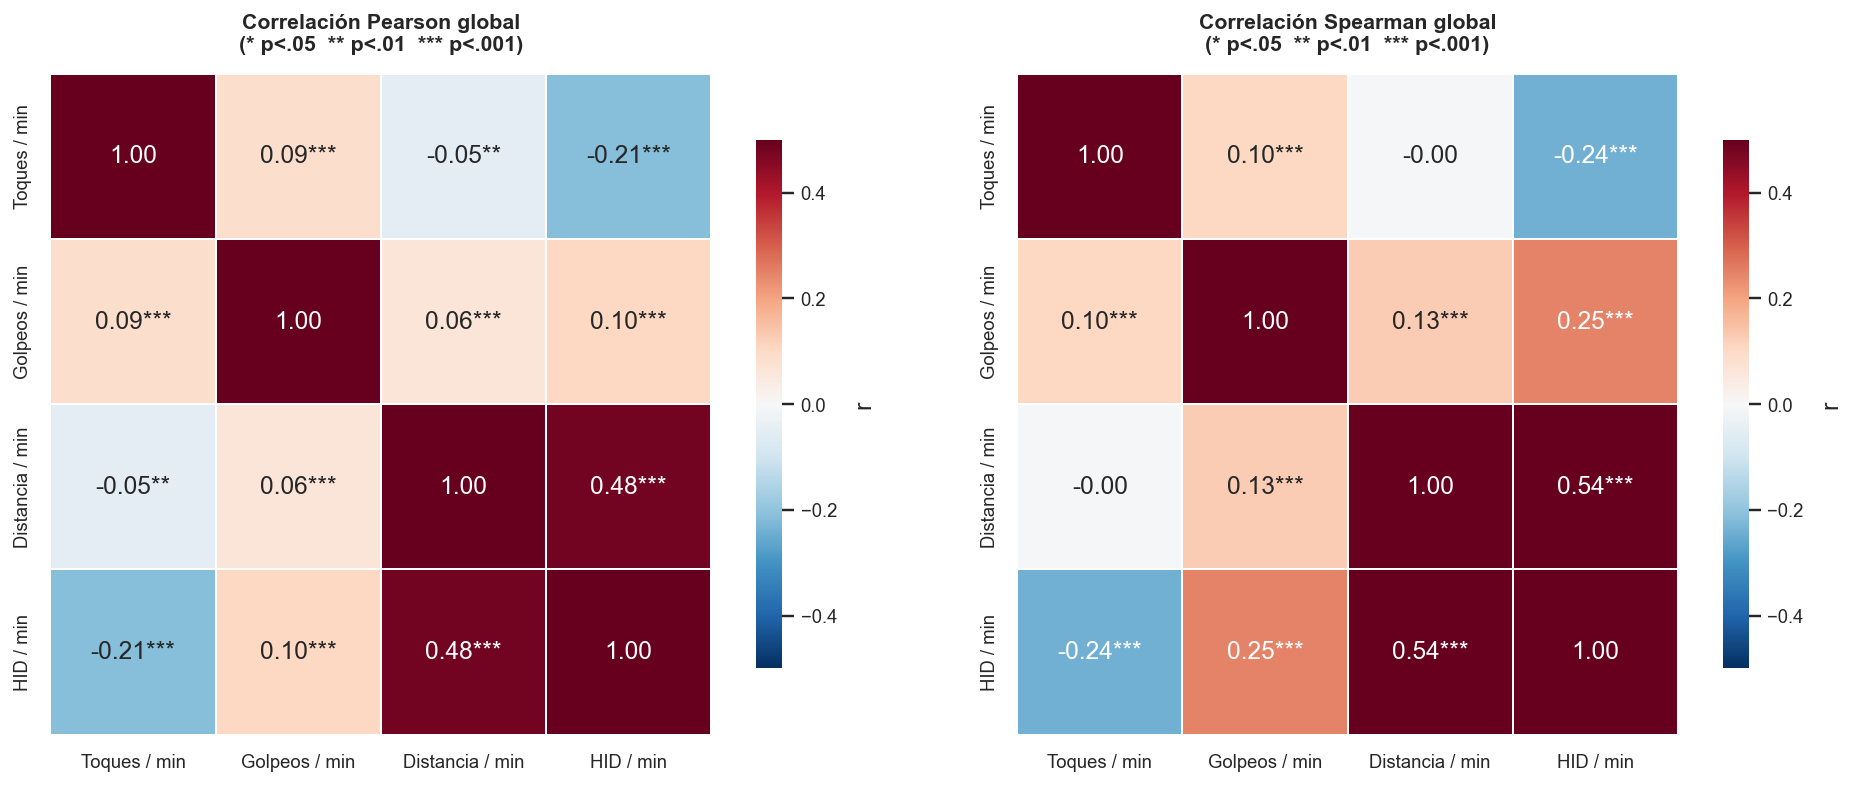

In [4]:
# ── Heatmaps lado a lado con anotaciones de significación ──
def sig_stars(p):
    """Devuelve estrellas de significación."""
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    return ""

def annot_matrix(corr_df, pval_df):
    """Crea una matriz de anotaciones con r y estrellas."""
    n = corr_df.shape[0]
    annot = np.empty((n, n), dtype=object)
    for i in range(n):
        for j in range(n):
            if i == j:
                annot[i, j] = "1.00"
            else:
                r = corr_df.iloc[i, j]
                stars = sig_stars(pval_df.iloc[i, j])
                annot[i, j] = f"{r:.2f}{stars}"
    return annot

annot_p = annot_matrix(corr_pearson, pval_pearson)
annot_s = annot_matrix(corr_spearman, pval_spearman)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
mask = np.triu(np.ones_like(corr_pearson, dtype=bool), k=0)

for ax, corr_df, annot, titulo in zip(
    axes,
    [corr_pearson, corr_spearman],
    [annot_p, annot_s],
    ["Pearson", "Spearman"],
):
    sns.heatmap(
        corr_df, annot=annot, fmt="",
        cmap="RdBu_r", center=0, vmin=-0.5, vmax=0.5,
        square=True, linewidths=1, linecolor="white",
        cbar_kws={"shrink": 0.8, "label": "r"},
        ax=ax,
    )
    ax.set_title(f"Correlación {titulo} global\n(* p<.05  ** p<.01  *** p<.001)",
                 fontsize=11, fontweight="bold")
    ax.tick_params(axis="both", labelsize=9.5)

plt.tight_layout()
plt.show()

In [5]:
# ── Correlaciones condicionadas (solo valores > 0) ─────────
# Para pares que involucran Golpeos/min o HID/min
pares_cond = []
for i in range(len(vd_cols)):
    for j in range(i + 1, len(vd_cols)):
        vd_i, vd_j = vd_cols[i], vd_cols[j]
        lab_i, lab_j = vd_labels[i], vd_labels[j]
        # Solo si al menos una de las VD tiene inflación de ceros
        if vd_i in vd_zeros or vd_j in vd_zeros:
            # Filtrar: ambas > 0
            mask_pos = (df[vd_i] > 0) & (df[vd_j] > 0)
            sub = df.loc[mask_pos]
            n_total = len(df.dropna(subset=[vd_i, vd_j]))
            n_pos = mask_pos.sum()
            r_full, p_full = stats.pearsonr(df[vd_i].dropna(), df[vd_j].dropna())
            if n_pos > 10:
                r_cond, p_cond = stats.pearsonr(sub[vd_i], sub[vd_j])
                rho_cond, p_rho = stats.spearmanr(sub[vd_i], sub[vd_j])
            else:
                r_cond, p_cond, rho_cond, p_rho = np.nan, np.nan, np.nan, np.nan
            pares_cond.append({
                "Par": f"{lab_i} × {lab_j}",
                "N total": n_total,
                "N (ambas > 0)": n_pos,
                "% retenido": f"{n_pos / n_total * 100:.1f}%",
                "r Pearson (global)": f"{r_full:.3f}",
                "r Pearson (> 0)": f"{r_cond:.3f}",
                "ρ Spearman (> 0)": f"{rho_cond:.3f}",
            })

df_cond = pd.DataFrame(pares_cond)
print("Correlaciones condicionadas (solo observaciones con ambas VD > 0):")
display(df_cond.style.set_caption(
    "Efecto de excluir ceros en las correlaciones"
).set_properties(**{"text-align": "center"}))

Correlaciones condicionadas (solo observaciones con ambas VD > 0):


,Par,N total,N (ambas > 0),% retenido,r Pearson (global),r Pearson (> 0),ρ Spearman (> 0)
0,Toques / min × Golpeos / min,3179,2306,72.5%,0.087,0.224,0.265
1,Toques / min × HID / min,3179,2251,70.8%,-0.215,-0.187,-0.207
2,Golpeos / min × Distancia / min,3179,2306,72.5%,0.063,-0.029,0.026
3,Golpeos / min × HID / min,3179,1813,57.0%,0.103,0.014,0.053
4,Distancia / min × HID / min,3179,2251,70.8%,0.482,0.427,0.444


### Interpretación — Correlaciones globales

**Estructura general:**
- **Dist × HID** es la correlación más fuerte (*r* = 0,48 Pearson, ρ = 0,54 Spearman, ambas ***p*** < .001). Ambas son métricas físicas y comparten un componente locomotor: quien más corre, tiende a cubrir más distancia a alta intensidad.
- **Toques × HID** es **negativa** (*r* = −0,21, ρ = −0,24, ambas ***p*** < .001): esto confirma el *trade-off* técnico-físico documentado en NB06. Las tareas que promueven más contactos con balón tienden a generar menor distancia a alta intensidad.
- **Toques × Golpeos** muestra correlación positiva débil (*r* = 0,09***, ρ = 0,10***), sugiriendo que son dimensiones parcialmente independientes del rendimiento técnico.
- **Golpeos × HID** es positiva baja (Pearson *r* = 0,10***, Spearman ρ = 0,25***); la discrepancia entre métodos señala que Spearman captura mejor la relación monótona cuando hay inflación de ceros.
- **Toques × Dist** es prácticamente nula (*r* = −0,05**, ρ ≈ 0,00 ns), reforzando la **independencia** entre la dimensión técnica y la locomotora.

**Pearson vs. Spearman:**
- Las discrepancias más notables aparecen en pares con inflación de ceros. Spearman amplifica **Dist × HID** (de 0,48 a 0,54) y **Golpeos × HID** (de 0,10 a 0,25) porque los rangos penalizan menos los empates en cero.
- Para **Toques × HID**, Spearman da un valor aún más negativo (−0,24 vs. −0,21), confirmando la robustez del trade-off.

**Efecto de excluir ceros:**
- Al calcular correlaciones condicionadas (ambas VD > 0), los coeficientes pueden cambiar apreciablemente, especialmente para pares como Golpeos × HID, donde la masa de ceros simultáneos infla artificialmente la asociación.

---
## 2. Scatterplots de los 6 pares de VD

Visualización directa de las relaciones bivariantes. Se usa alpha bajo y tamaño pequeño de punto para manejar el *overplotting* con 3 179 observaciones.

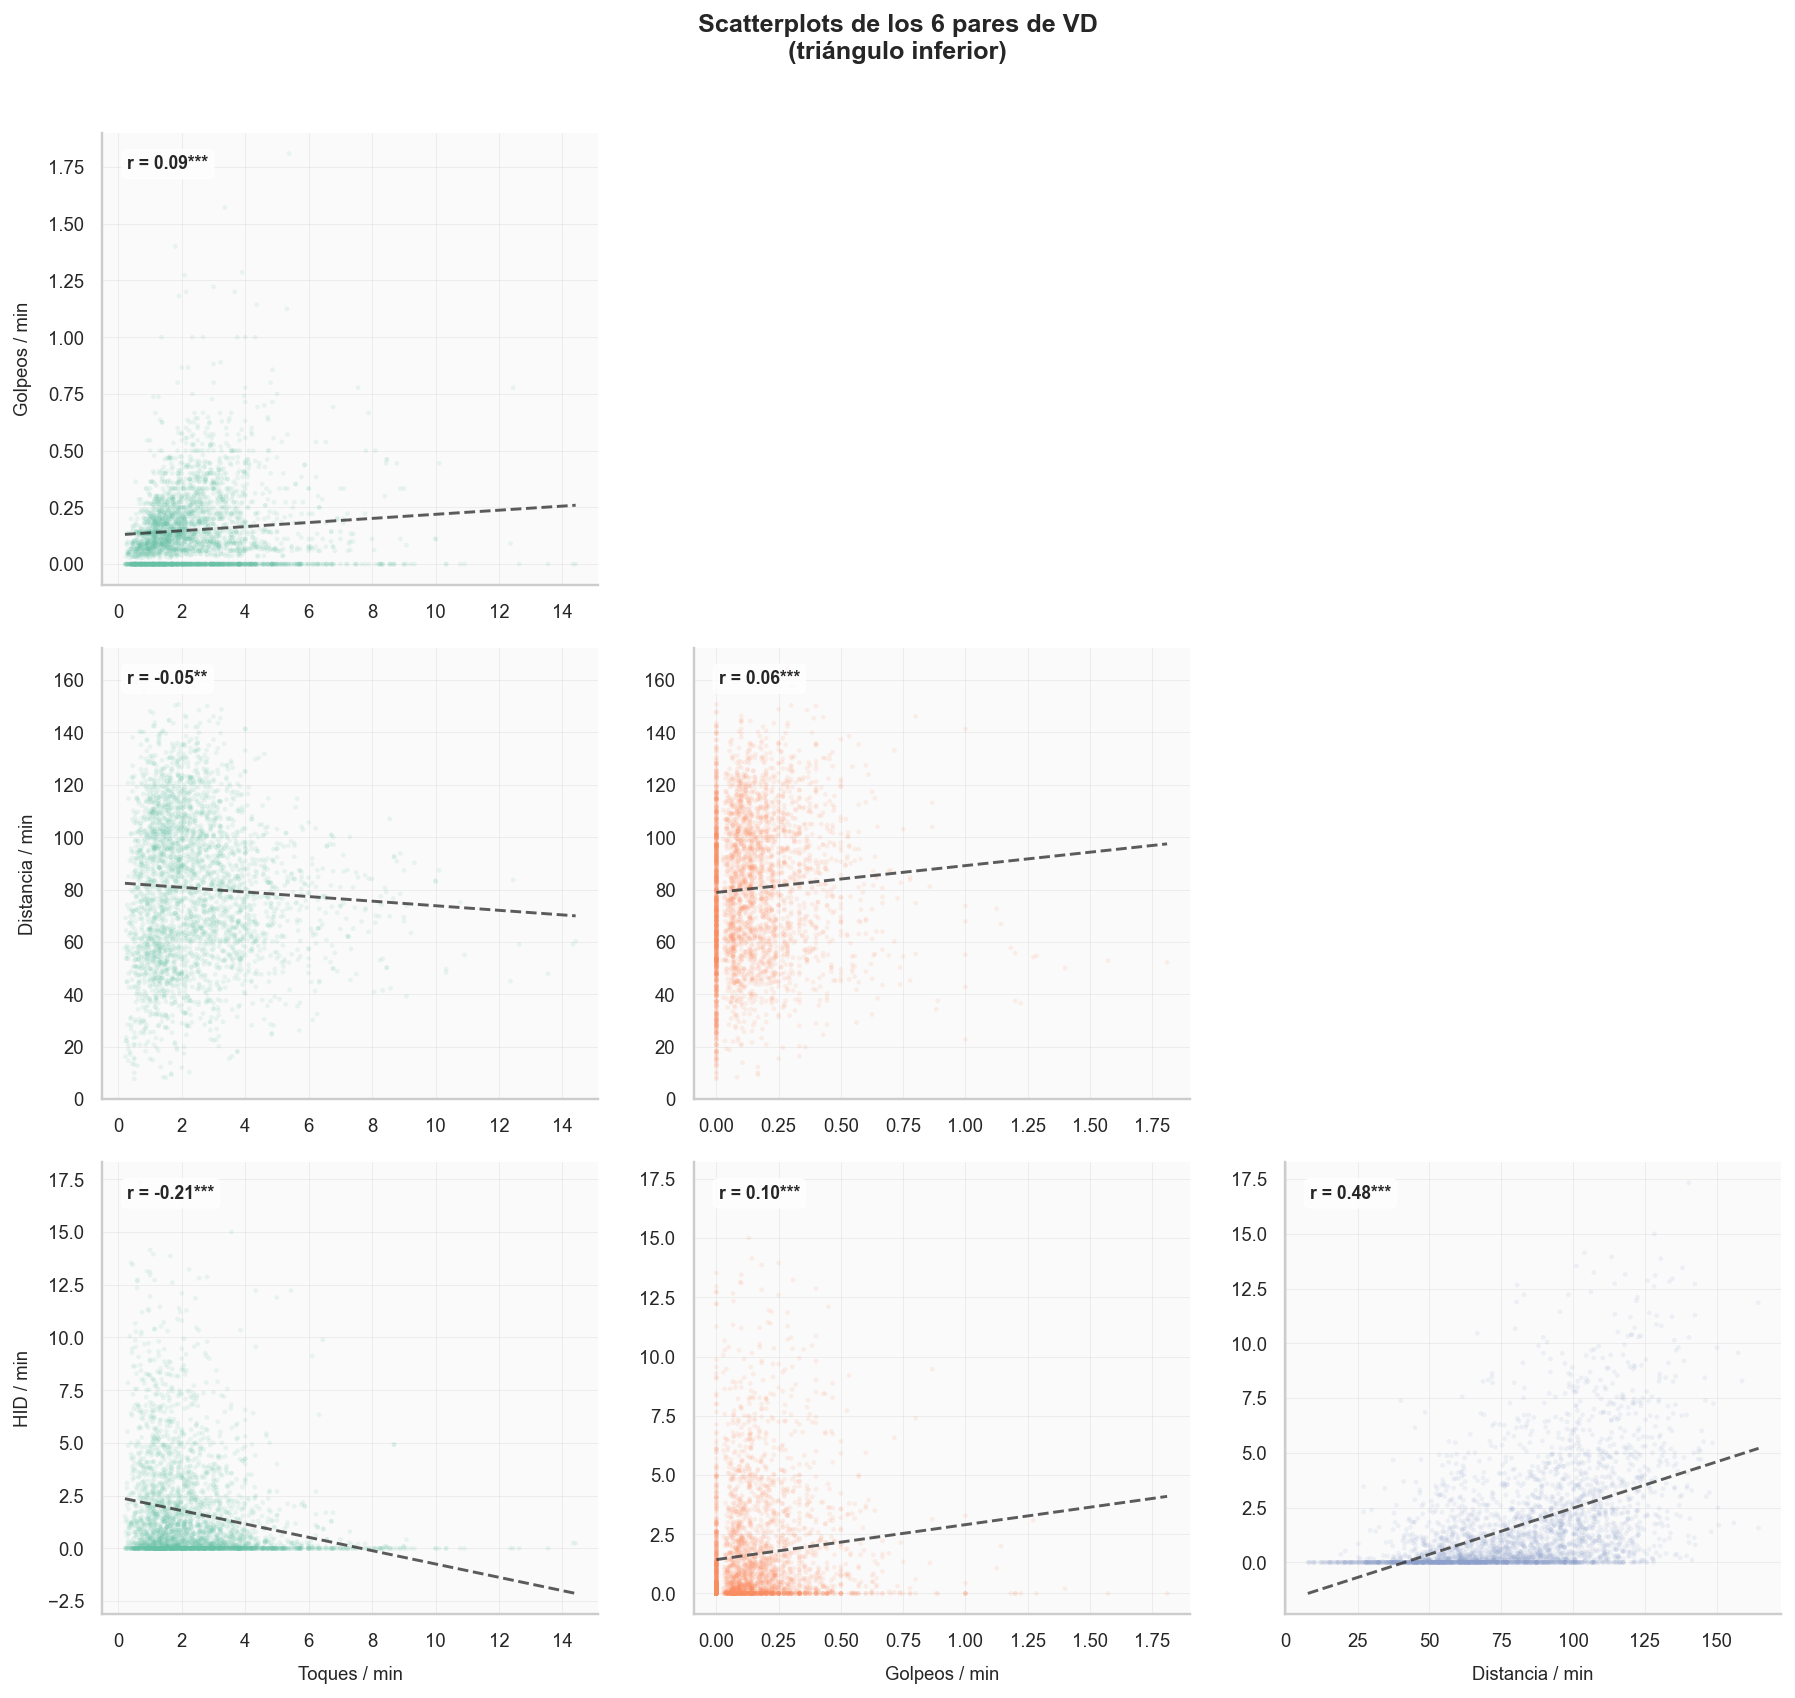

In [6]:
# ── Matriz de scatterplots (triángulo inferior) ────────────
n_vd = len(vd_cols)
fig, axes = plt.subplots(n_vd - 1, n_vd - 1, figsize=(13, 12))

for i in range(n_vd - 1):
    for j in range(n_vd - 1):
        ax = axes[i][j]
        if j > i:
            ax.set_visible(False)
            continue
        # Mapear: fila i -> VD[i+1], columna j -> VD[j]
        vd_x = vd_cols[j]
        vd_y = vd_cols[i + 1]
        lab_x = vd_labels[j]
        lab_y = vd_labels[i + 1]

        ax.scatter(df[vd_x], df[vd_y], alpha=0.12, s=6,
                   color=colores_vd[j], edgecolors="none", rasterized=True)

        # Línea de regresión
        mask_valid = df[[vd_x, vd_y]].dropna().index
        x_vals = df.loc[mask_valid, vd_x].values
        y_vals = df.loc[mask_valid, vd_y].values
        slope, intercept, r_val, p_val, _ = stats.linregress(x_vals, y_vals)
        x_line = np.linspace(x_vals.min(), x_vals.max(), 100)
        ax.plot(x_line, slope * x_line + intercept, color="#333333",
                linewidth=1.5, linestyle="--", alpha=0.8)

        # Anotación del coeficiente
        sig = sig_stars(p_val)
        ax.annotate(f"r = {r_val:.2f}{sig}", xy=(0.05, 0.92),
                    xycoords="axes fraction", fontsize=9, fontweight="bold",
                    bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8))

        if j == 0:
            ax.set_ylabel(lab_y, fontsize=9.5)
        else:
            ax.set_ylabel("")
        if i == n_vd - 2:
            ax.set_xlabel(lab_x, fontsize=9.5)
        else:
            ax.set_xlabel("")

fig.suptitle("Scatterplots de los 6 pares de VD\n(triángulo inferior)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

Niveles de Formato_del_Juego: ['LSG', 'SSG']


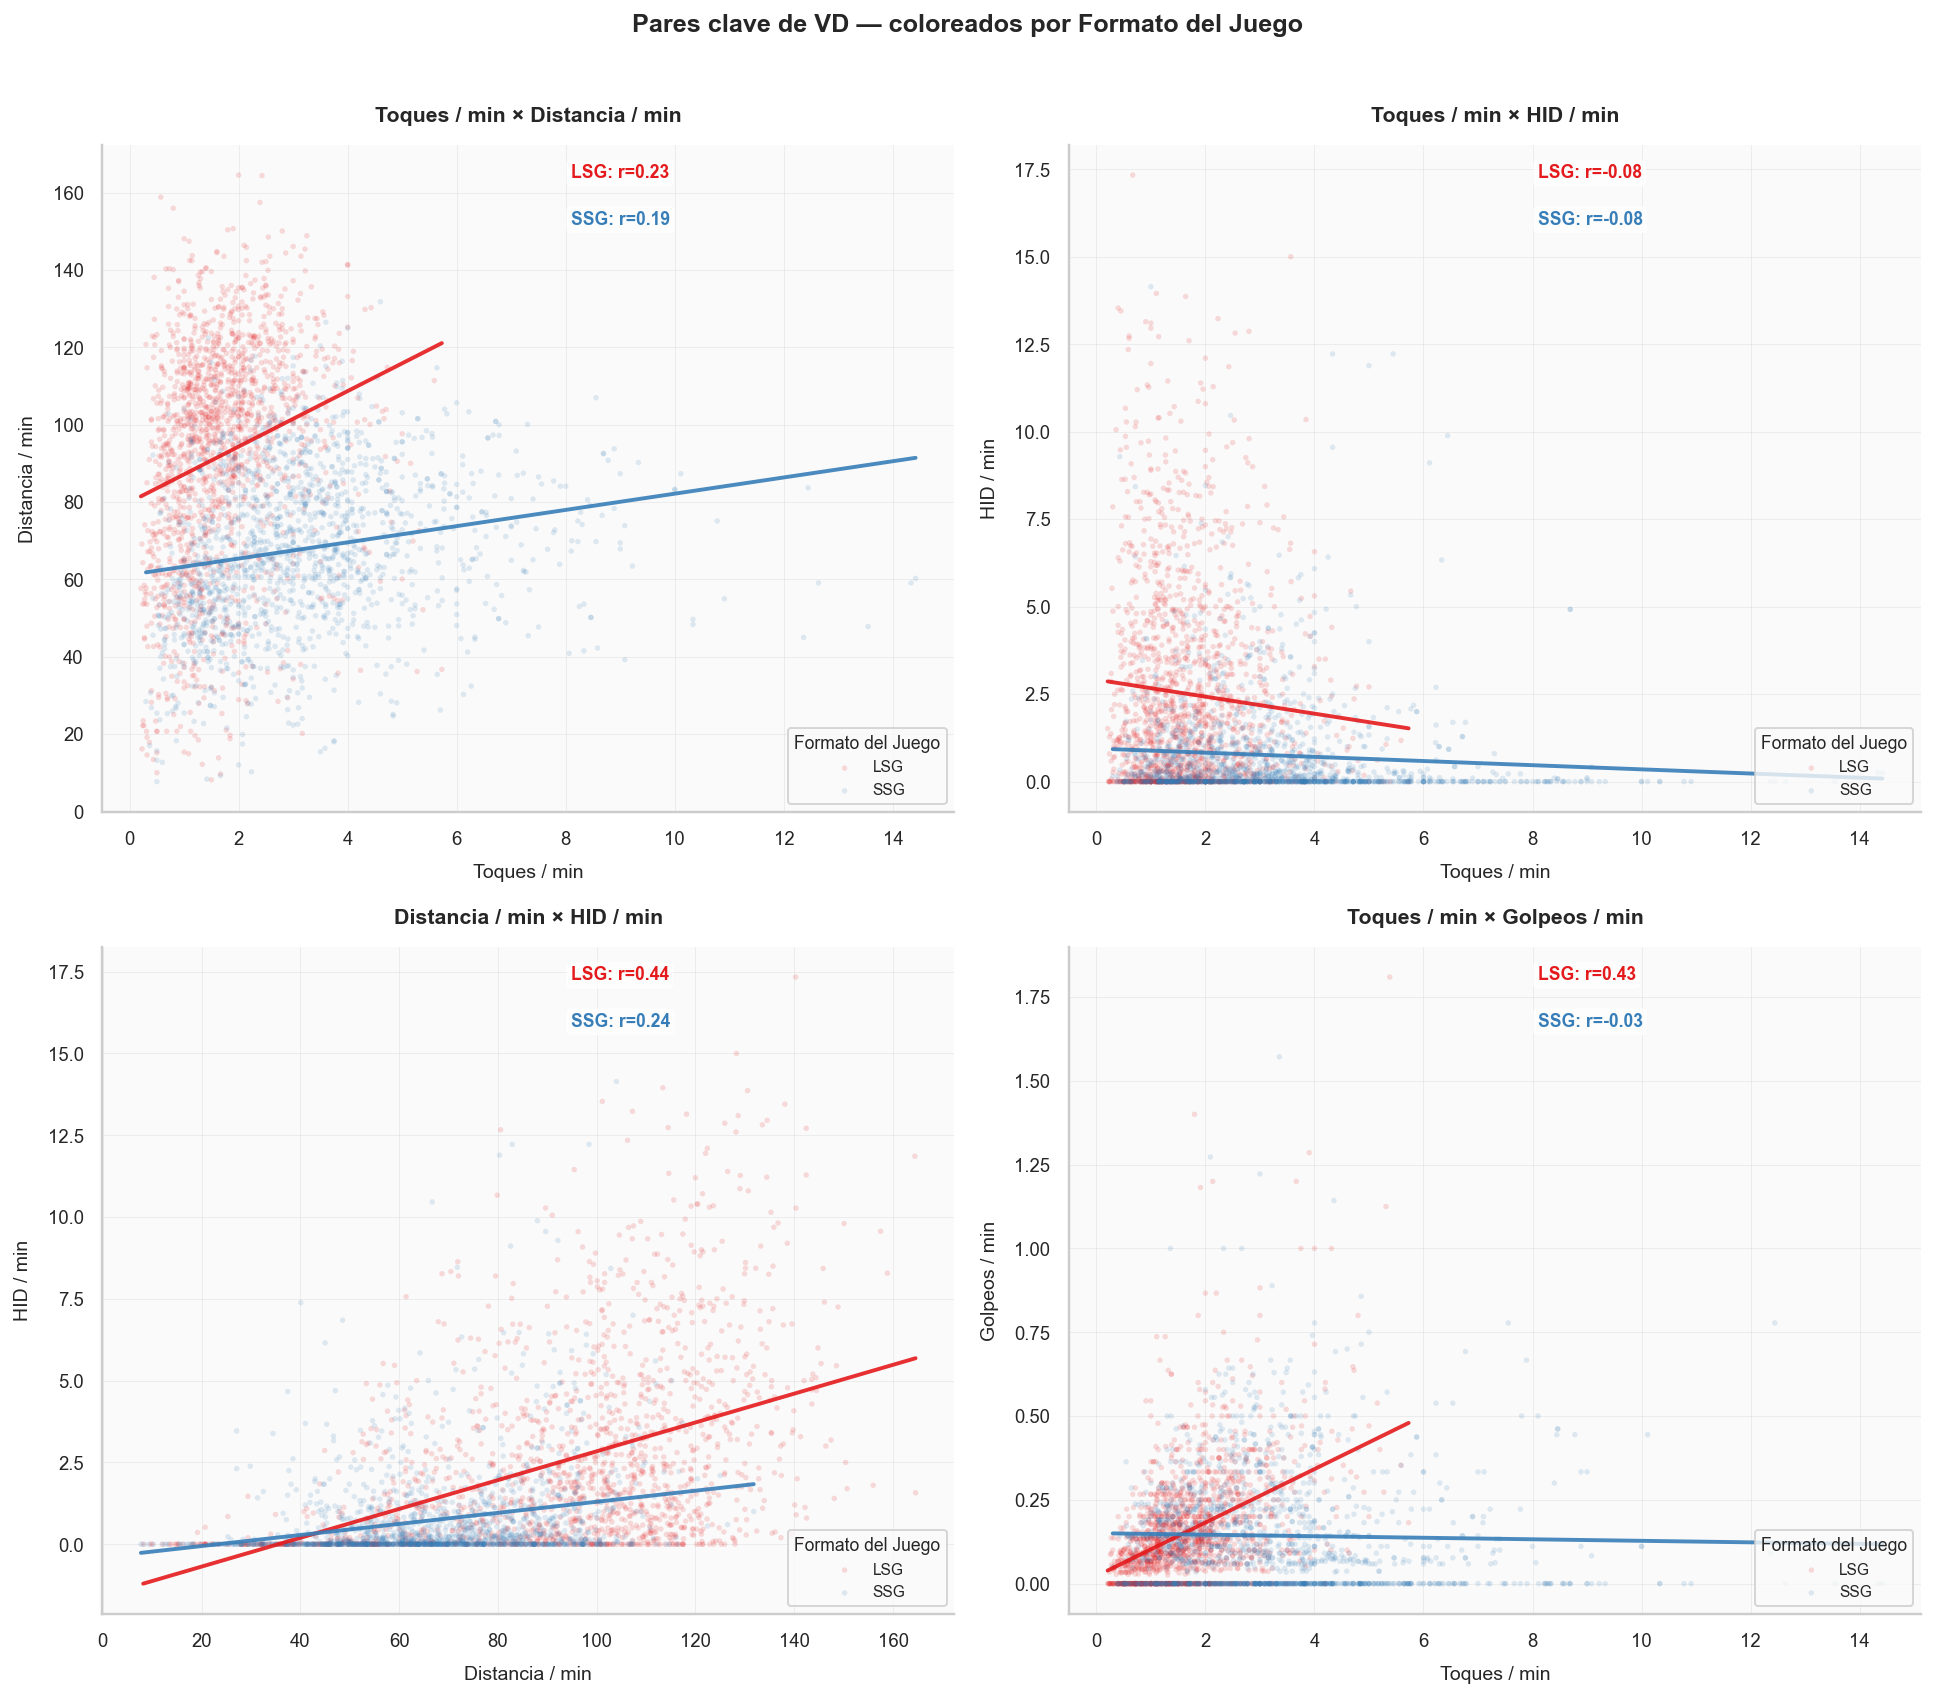

In [7]:
# ── Detectar niveles reales de Formato_del_Juego ───────────
niveles_formato = sorted(df["Formato_del_Juego"].dropna().unique().tolist())
print(f"Niveles de Formato_del_Juego: {niveles_formato}")

# ── 4 scatterplots individuales coloreados por Formato_del_Juego ─
pares_clave = [
    ("Total Touches / min", "Distance Covered (m) / min",
     "Toques / min", "Distancia / min"),
    ("Total Touches / min", "High Intensity Distance (20 km/h) / min",
     "Toques / min", "HID / min"),
    ("Distance Covered (m) / min", "High Intensity Distance (20 km/h) / min",
     "Distancia / min", "HID / min"),
    ("Total Touches / min", "Golpeos +15 m/s / min",
     "Toques / min", "Golpeos / min"),
]

pal_formato = sns.color_palette("Set1", n_colors=len(niveles_formato))
colores_formato = dict(zip(niveles_formato, pal_formato))

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes_flat = axes.flatten()

for idx, (vd_x, vd_y, lab_x, lab_y) in enumerate(pares_clave):
    ax = axes_flat[idx]
    for nivel in niveles_formato:
        color = colores_formato[nivel]
        sub = df[df["Formato_del_Juego"] == nivel]
        ax.scatter(sub[vd_x], sub[vd_y], alpha=0.15, s=8,
                   color=color, label=nivel, edgecolors="none", rasterized=True)
        # Línea de regresión por nivel
        sub_clean = sub[[vd_x, vd_y]].dropna()
        x_s = sub_clean[vd_x].values
        y_s = sub_clean[vd_y].values
        if len(x_s) > 10:
            slope, intercept, r_val, _, _ = stats.linregress(x_s, y_s)
            x_line = np.linspace(x_s.min(), x_s.max(), 100)
            ax.plot(x_line, slope * x_line + intercept, color=color,
                    linewidth=2, linestyle="-", alpha=0.9)
            y_offset = 0.95 if nivel == niveles_formato[0] else 0.88
            ax.annotate(f"{nivel}: r={r_val:.2f}",
                        xy=(0.55, y_offset),
                        xycoords="axes fraction", fontsize=9,
                        color=color, fontweight="bold",
                        bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7))

    ax.set_xlabel(lab_x, fontsize=10)
    ax.set_ylabel(lab_y, fontsize=10)
    ax.set_title(f"{lab_x} × {lab_y}", fontsize=11, fontweight="bold")
    ax.legend(title="Formato del Juego", fontsize=8, title_fontsize=9, loc="lower right")

fig.suptitle("Pares clave de VD — coloreados por Formato del Juego",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### Interpretación — Scatterplots

- **Toques × Distancia**: relación débil (*r* = −0,05**), nube amplia sin estructura clara. Las líneas de regresión por Formato del Juego son casi paralelas (LSG: *r* = 0,23; SSG: *r* = 0,19).
- **Toques × HID**: relación negativa visible (*r* = −0,21***); la nube se inclina ligeramente hacia abajo. Dentro de cada formato la pendiente es similar (LSG: *r* = −0,08; SSG: *r* = −0,08).
- **Distancia × HID**: la relación positiva más clara de todas (*r* = 0,48***). Se observa una nube elongada a lo largo de la diagonal, con pendiente más pronunciada en LSG (*r* = 0,44) que en SSG (*r* = 0,24).
- **Toques × Golpeos**: máxima heterogeneidad por Formato del Juego — en LSG la pendiente es claramente positiva (*r* = 0,43***) mientras que en SSG es plana (*r* ≈ 0). El test de Fisher confirma la diferencia (*p* < .0001).
- El *overplotting* es manejable con alpha = 0.15 y s = 8, aunque la densidad es alta en el centro de la nube.

---
## 3. ¿Cambia la correlación según el tipo de tarea?

Para cada par de VD clave, calculamos la correlación de Pearson por separado para cada nivel de cada VI (6 subgrupos: 2 niveles × 3 VIs). Usamos el **test de Fisher *z*** para evaluar si la diferencia entre correlaciones es significativa.

In [8]:
# ── Función: test de Fisher para comparación de correlaciones ──
def fisher_z_test(r1, n1, r2, n2):
    """Test de Fisher para la diferencia entre dos correlaciones independientes."""
    # Transformación z de Fisher
    z1 = np.arctanh(np.clip(r1, -0.999, 0.999))
    z2 = np.arctanh(np.clip(r2, -0.999, 0.999))
    se = np.sqrt(1 / (n1 - 3) + 1 / (n2 - 3))
    z_stat = (z1 - z2) / se
    p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))
    return z_stat, p_value

def ci_pearson_r(r, n, alpha=0.05):
    """IC 95% para r de Pearson mediante transformación de Fisher."""
    z = np.arctanh(np.clip(r, -0.999, 0.999))
    se = 1 / np.sqrt(n - 3)
    z_crit = stats.norm.ppf(1 - alpha / 2)
    lo = np.tanh(z - z_crit * se)
    hi = np.tanh(z + z_crit * se)
    return lo, hi

# ── Pares de VD a analizar ─────────────────────────────────
pares_analisis = [
    ("Total Touches / min", "Distance Covered (m) / min",
     "Toques × Dist"),
    ("Total Touches / min", "High Intensity Distance (20 km/h) / min",
     "Toques × HID"),
    ("Distance Covered (m) / min", "High Intensity Distance (20 km/h) / min",
     "Dist × HID"),
    ("Total Touches / min", "Golpeos +15 m/s / min",
     "Toques × Golpeos"),
]

# ── Calcular correlaciones por VI y nivel ──────────────────
resultados = []
for vd_x, vd_y, par_label in pares_analisis:
    for vi in vi_cols:
        niveles_vi = sorted(df[vi].dropna().unique())
        datos_niveles = {}  # Para el test de Fisher
        for nivel in niveles_vi:
            sub = df[df[vi] == nivel].dropna(subset=[vd_x, vd_y])
            n = len(sub)
            if n > 10:
                r, p = stats.pearsonr(sub[vd_x], sub[vd_y])
                lo, hi = ci_pearson_r(r, n)
            else:
                r, p, lo, hi = np.nan, np.nan, np.nan, np.nan
            datos_niveles[nivel] = {"r": r, "n": n, "p": p}
            resultados.append({
                "Par": par_label, "VI": vi, "Nivel": nivel,
                "n": n, "r": r, "IC_lo": lo, "IC_hi": hi,
                "p": p, "sig": sig_stars(p),
            })
        # Test de Fisher entre los dos niveles
        if len(niveles_vi) == 2:
            d1 = datos_niveles[niveles_vi[0]]
            d2 = datos_niveles[niveles_vi[1]]
            if not (np.isnan(d1["r"]) or np.isnan(d2["r"])):
                z_fish, p_fish = fisher_z_test(d1["r"], d1["n"], d2["r"], d2["n"])
                # Añadir info del test al último resultado de este par-VI
                resultados[-1]["Fisher_z"] = z_fish
                resultados[-1]["Fisher_p"] = p_fish
                resultados[-2]["Fisher_z"] = z_fish
                resultados[-2]["Fisher_p"] = p_fish

df_corr_vi = pd.DataFrame(resultados)

# ── Tabla resumen ──────────────────────────────────────────
display(Markdown("### Tabla resumen: correlación de Pearson por nivel de cada VI"))
tabla_resumen = df_corr_vi.copy()
tabla_resumen["r [IC 95%]"] = tabla_resumen.apply(
    lambda row: f"{row['r']:.3f} [{row['IC_lo']:.3f}, {row['IC_hi']:.3f}]{row['sig']}",
    axis=1
)
tabla_resumen["Δ sig. (Fisher)"] = tabla_resumen["Fisher_p"].apply(
    lambda x: f"p = {x:.4f} {sig_stars(x)}" if pd.notna(x) else ""
)
display(
    tabla_resumen[["Par", "VI", "Nivel", "n", "r [IC 95%]", "Δ sig. (Fisher)"]]
    .style.set_properties(**{"text-align": "center"})
    .set_caption("Correlaciones de Pearson por subgrupo de tarea")
)

### Tabla resumen: correlación de Pearson por nivel de cada VI

,Par,VI,Nivel,n,r [IC 95%],Δ sig. (Fisher)
0,Toques × Dist,Formato_del_Juego,LSG,1637,"0.230 [0.184, 0.276]***",p = 0.2840
1,Toques × Dist,Formato_del_Juego,SSG,1542,"0.194 [0.146, 0.242]***",p = 0.2840
2,Toques × Dist,Polaridad,No_polarizado,649,"-0.043 [-0.119, 0.035]",p = 0.6134
3,Toques × Dist,Polaridad,Polarizado,2530,"-0.020 [-0.059, 0.019]",p = 0.6134
4,Toques × Dist,Equilibrio,Desequilibrio,798,"0.014 [-0.055, 0.084]",p = 0.7419
5,Toques × Dist,Equilibrio,Equilibrio,2381,"0.001 [-0.039, 0.041]",p = 0.7419
6,Toques × HID,Formato_del_Juego,LSG,1637,"-0.079 [-0.126, -0.030]**",p = 0.9772
7,Toques × HID,Formato_del_Juego,SSG,1542,"-0.078 [-0.127, -0.028]**",p = 0.9772
8,Toques × HID,Polaridad,No_polarizado,649,"-0.082 [-0.158, -0.005]*",p = 0.0089 **
9,Toques × HID,Polaridad,Polarizado,2530,"-0.195 [-0.232, -0.157]***",p = 0.0089 **


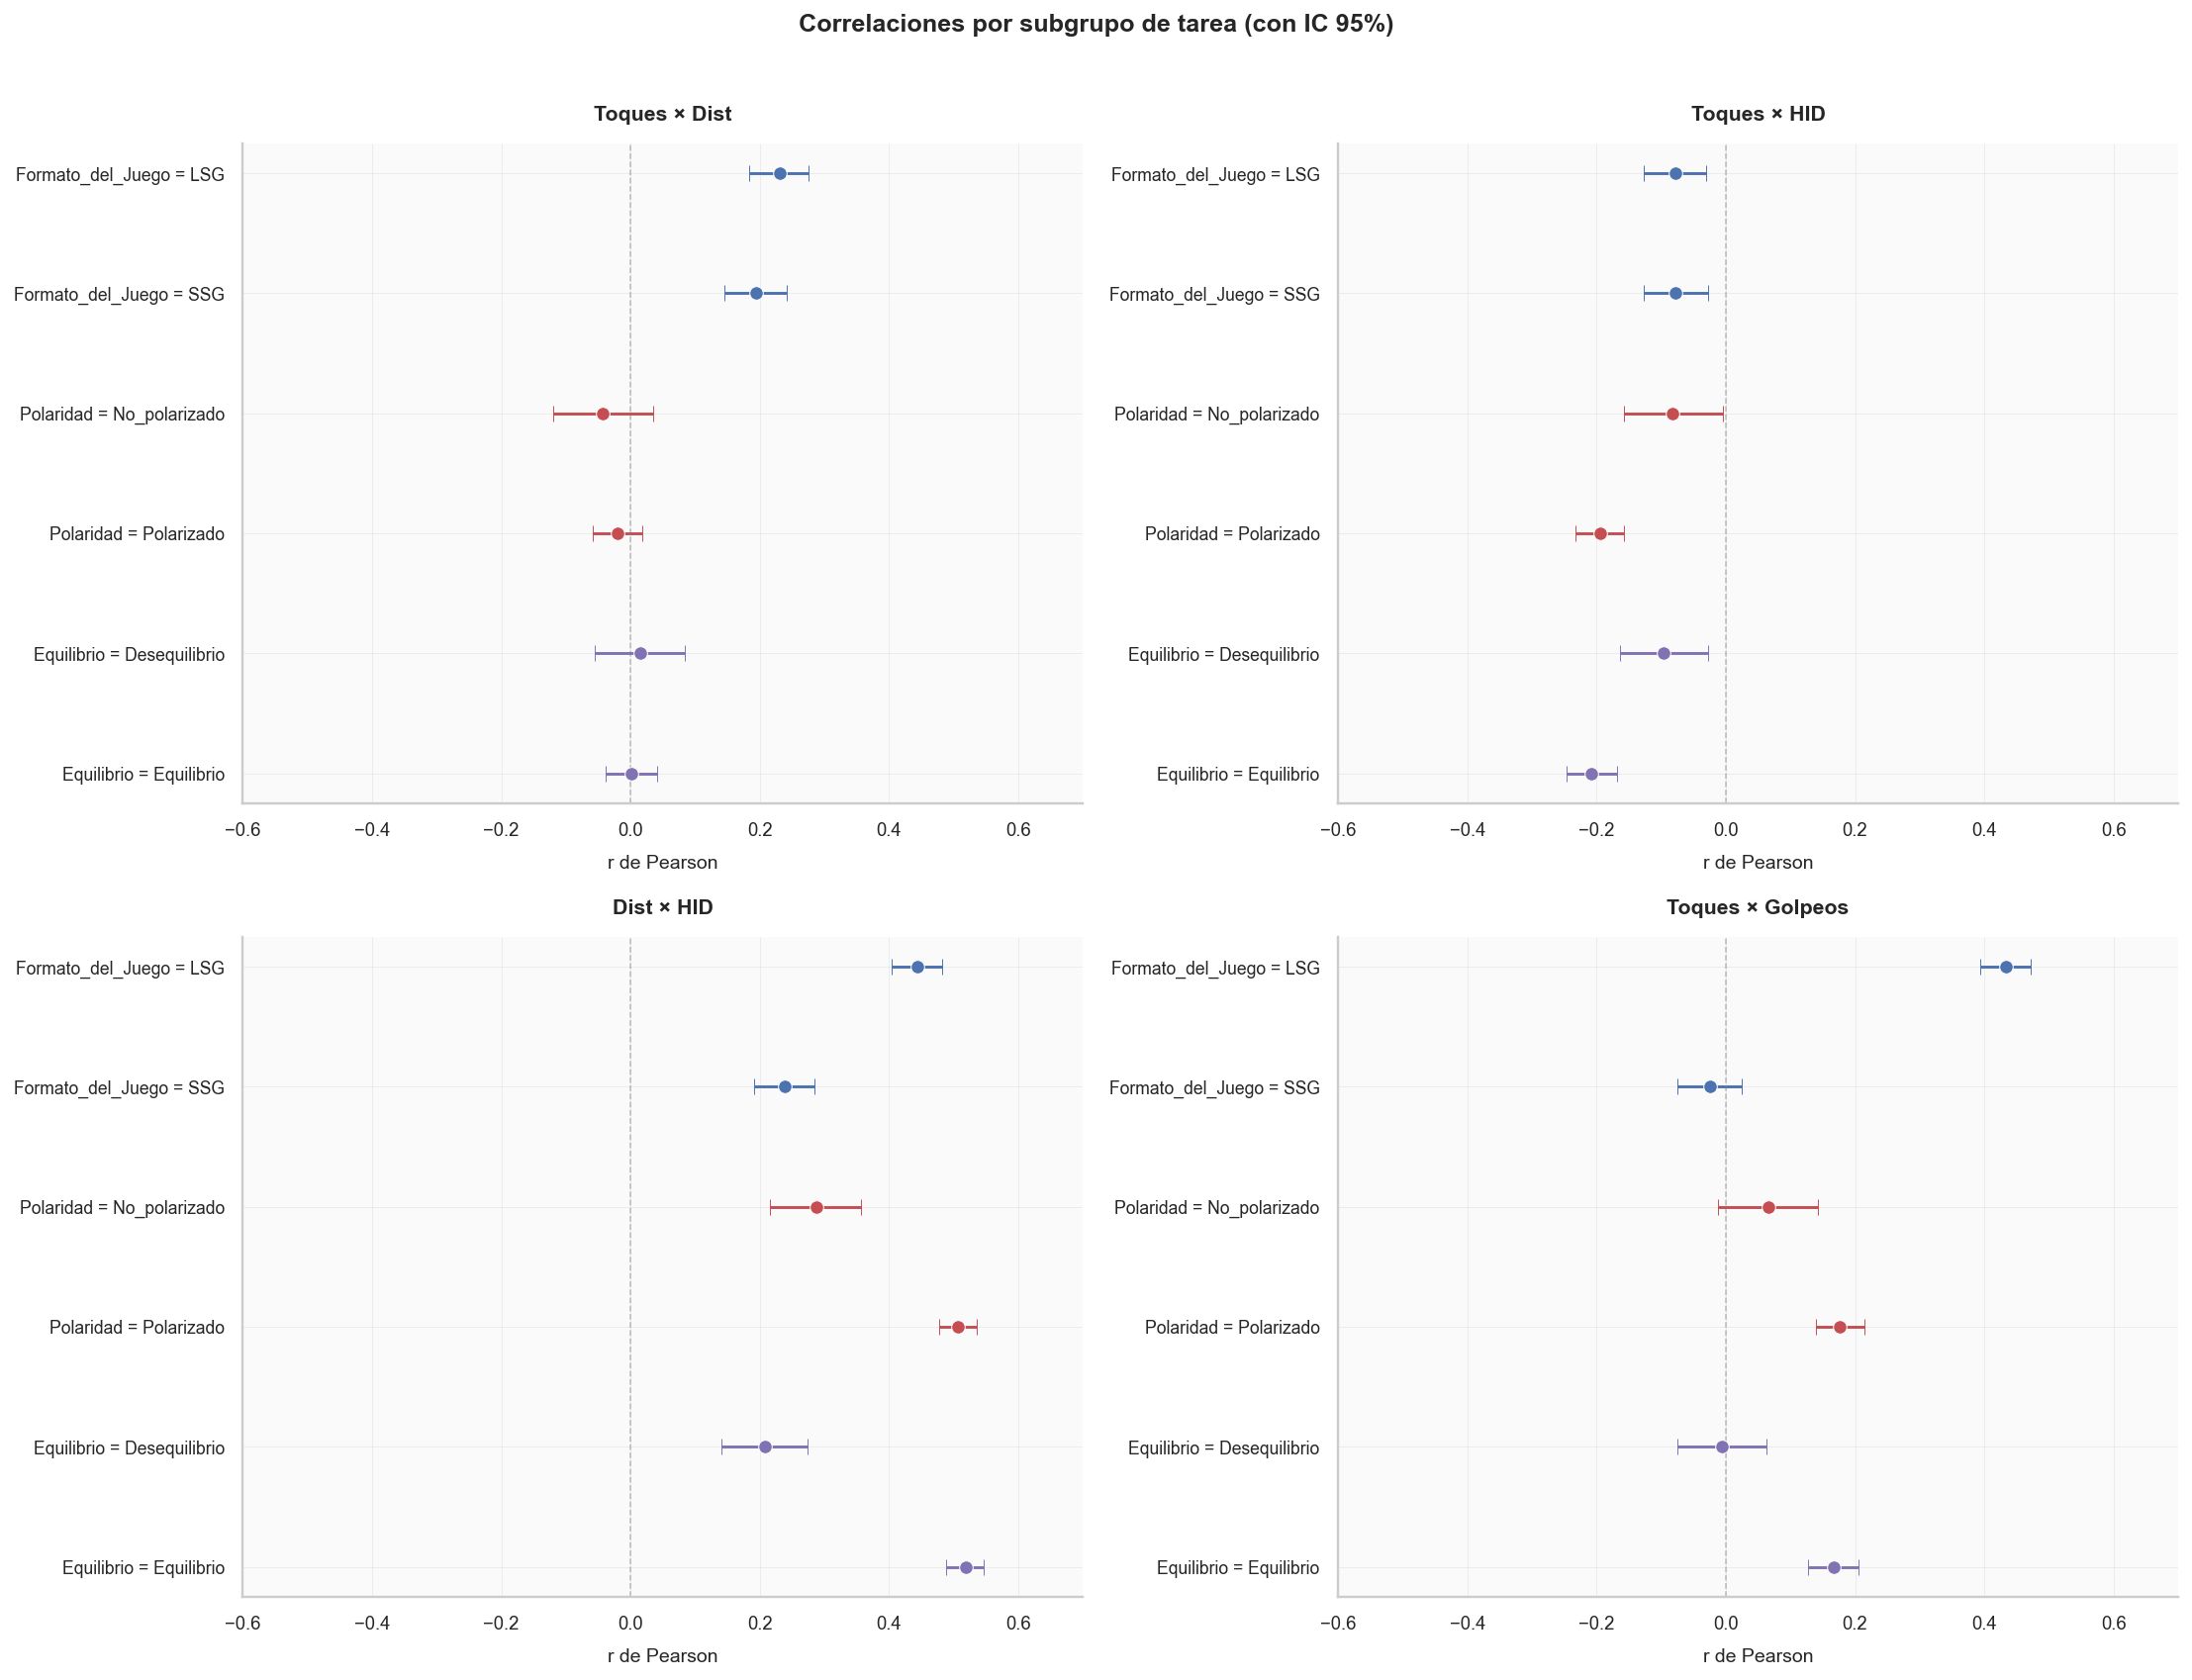

In [9]:
# ── Forest plot / dot plot de correlaciones por subgrupo ───
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes_flat = axes.flatten()

colores_vi = {
    "Formato_del_Juego": "#4C72B0",
    "Polaridad": "#C44E52", "Equilibrio": "#8172B3",
}

for idx, (_, _, par_label) in enumerate(pares_analisis):
    ax = axes_flat[idx]
    sub = df_corr_vi[df_corr_vi["Par"] == par_label].copy()
    sub["etiqueta"] = sub["VI"] + " = " + sub["Nivel"].astype(str)

    y_pos = np.arange(len(sub))
    for i, (_, row) in enumerate(sub.iterrows()):
        color = colores_vi[row["VI"]]
        ax.errorbar(
            row["r"], i, xerr=[[row["r"] - row["IC_lo"]], [row["IC_hi"] - row["r"]]],
            fmt="o", color=color, markersize=7, capsize=4, linewidth=1.5,
            markeredgecolor="white", markeredgewidth=0.5,
        )

    ax.axvline(0, color="grey", linewidth=0.8, linestyle="--", alpha=0.5)
    # Línea de la correlación global
    r_global = df_corr_vi[
        (df_corr_vi["Par"] == par_label)
    ]["r"].mean()
    ax.set_yticks(y_pos)
    ax.set_yticklabels(sub["etiqueta"].values, fontsize=9)
    ax.set_xlabel("r de Pearson", fontsize=10)
    ax.set_title(par_label, fontsize=11, fontweight="bold")
    ax.set_xlim(-0.6, 0.7)
    ax.invert_yaxis()

fig.suptitle("Correlaciones por subgrupo de tarea (con IC 95%)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### Interpretación — Correlaciones por tipo de tarea

**Hallazgo principal: Toques × Golpeos cambia drásticamente con el Formato del Juego.**

- En **LSG** (juego en espacios grandes), la correlación es positiva moderada-alta (*r* = 0,43***). En contextos abiertos, los jugadores que más tocan el balón también golpean más frecuentemente a alta velocidad. Esto es coherente: en espacios grandes hay más oportunidades de pase largo y tiro.
- En **SSG** (juego en espacios pequeños), la correlación es prácticamente nula (*r* = −0,03 ns). En contextos reducidos, los golpeos a alta velocidad son infrecuentes (poco espacio para armar) e independientes del volumen de toques.
- El **test de Fisher** confirma que la diferencia es altamente significativa (*p* < .0001***).

**Otros patrones notables:**
- **Toques × HID**: la correlación negativa es estable (LSG: *r* = −0,08**, SSG: *r* = −0,08**; Fisher *p* = .977 ns), lo que sugiere que el trade-off técnico-físico es una propiedad *intrínseca* de las tareas de entrenamiento, no un artefacto de un solo factor.
- **Dist × HID**: la correlación positiva es significativamente más fuerte en LSG (*r* = 0,44***) que en SSG (*r* = 0,24***), Fisher *p* < .0001***. El formato amplio amplifica la coherencia locomotora.
- **Toques × Dist**: positiva baja en ambos formatos (LSG: *r* = 0,23***, SSG: *r* = 0,19***); sin diferencia significativa (Fisher *p* = .284 ns).
- Las VIs con menor efecto modulador son **Polaridad** y **Equilibrio**, que apenas modifican la estructura correlacional.

---
## 4. Correlaciones por GrupoEdad

¿La estructura relacional entre las VD cambia con la edad de los jugadores? Calculamos la matriz de correlación (Pearson y Spearman) por cada GrupoEdad y las comparamos visualmente.

In [10]:
# ── Matrices de correlación por GrupoEdad ─────────────────
grupos_edad = ["Infantil", "Cadete", "Juvenil", "Senior Masculino", "Neskak"]
# Ordenar por etapa formativa + Neskak aparte

corr_por_grupo_p = {}  # Pearson
corr_por_grupo_s = {}  # Spearman
n_por_grupo = {}

for grp in grupos_edad:
    sub = df[df["GrupoEdad"] == grp]
    n_por_grupo[grp] = len(sub)
    corr_p, _ = corr_matrix_with_pvalues(sub, vd_cols, "pearson")
    corr_s, _ = corr_matrix_with_pvalues(sub, vd_cols, "spearman")
    corr_por_grupo_p[grp] = corr_p
    corr_por_grupo_s[grp] = corr_s

print("Observaciones por GrupoEdad:")
for grp in grupos_edad:
    print(f"  {grp}: n = {n_por_grupo[grp]}")

Observaciones por GrupoEdad:
  Infantil: n = 365
  Cadete: n = 579
  Juvenil: n = 771
  Senior Masculino: n = 653
  Neskak: n = 811


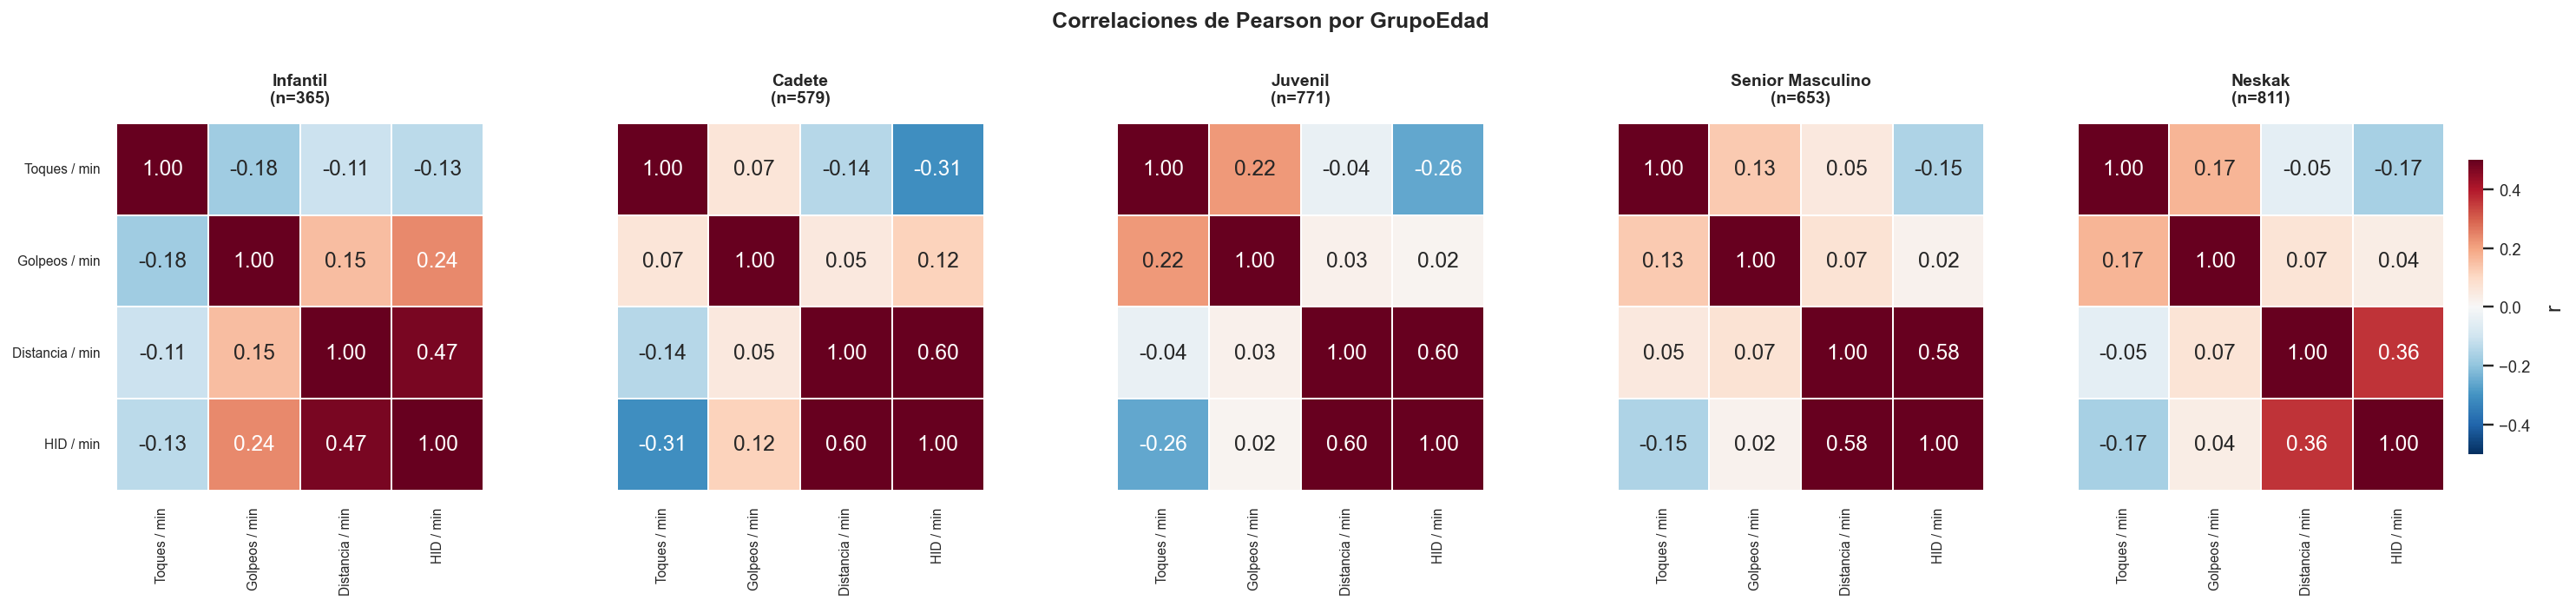

In [11]:
# ── 5 heatmaps Pearson (uno por GrupoEdad) ────────────────
fig, axes = plt.subplots(1, 5, figsize=(22, 4.5))

for idx, grp in enumerate(grupos_edad):
    ax = axes[idx]
    corr_df = corr_por_grupo_p[grp]
    # Anotaciones simples
    annot_vals = corr_df.values.copy()
    annot_str = np.array([[f"{v:.2f}" for v in row] for row in annot_vals])
    sns.heatmap(
        corr_df, annot=annot_str, fmt="",
        cmap="RdBu_r", center=0, vmin=-0.5, vmax=0.5,
        square=True, linewidths=1, linecolor="white",
        cbar=idx == 4,
        cbar_kws={"shrink": 0.8, "label": "r"} if idx == 4 else {},
        ax=ax,
    )
    ax.set_title(f"{grp}\n(n={n_por_grupo[grp]})",
                 fontsize=10, fontweight="bold")
    if idx > 0:
        ax.set_yticklabels([])
        ax.set_ylabel("")
    ax.tick_params(axis="both", labelsize=8)

fig.suptitle("Correlaciones de Pearson por GrupoEdad",
             fontsize=13, fontweight="bold", y=1.05)
plt.tight_layout()
plt.show()

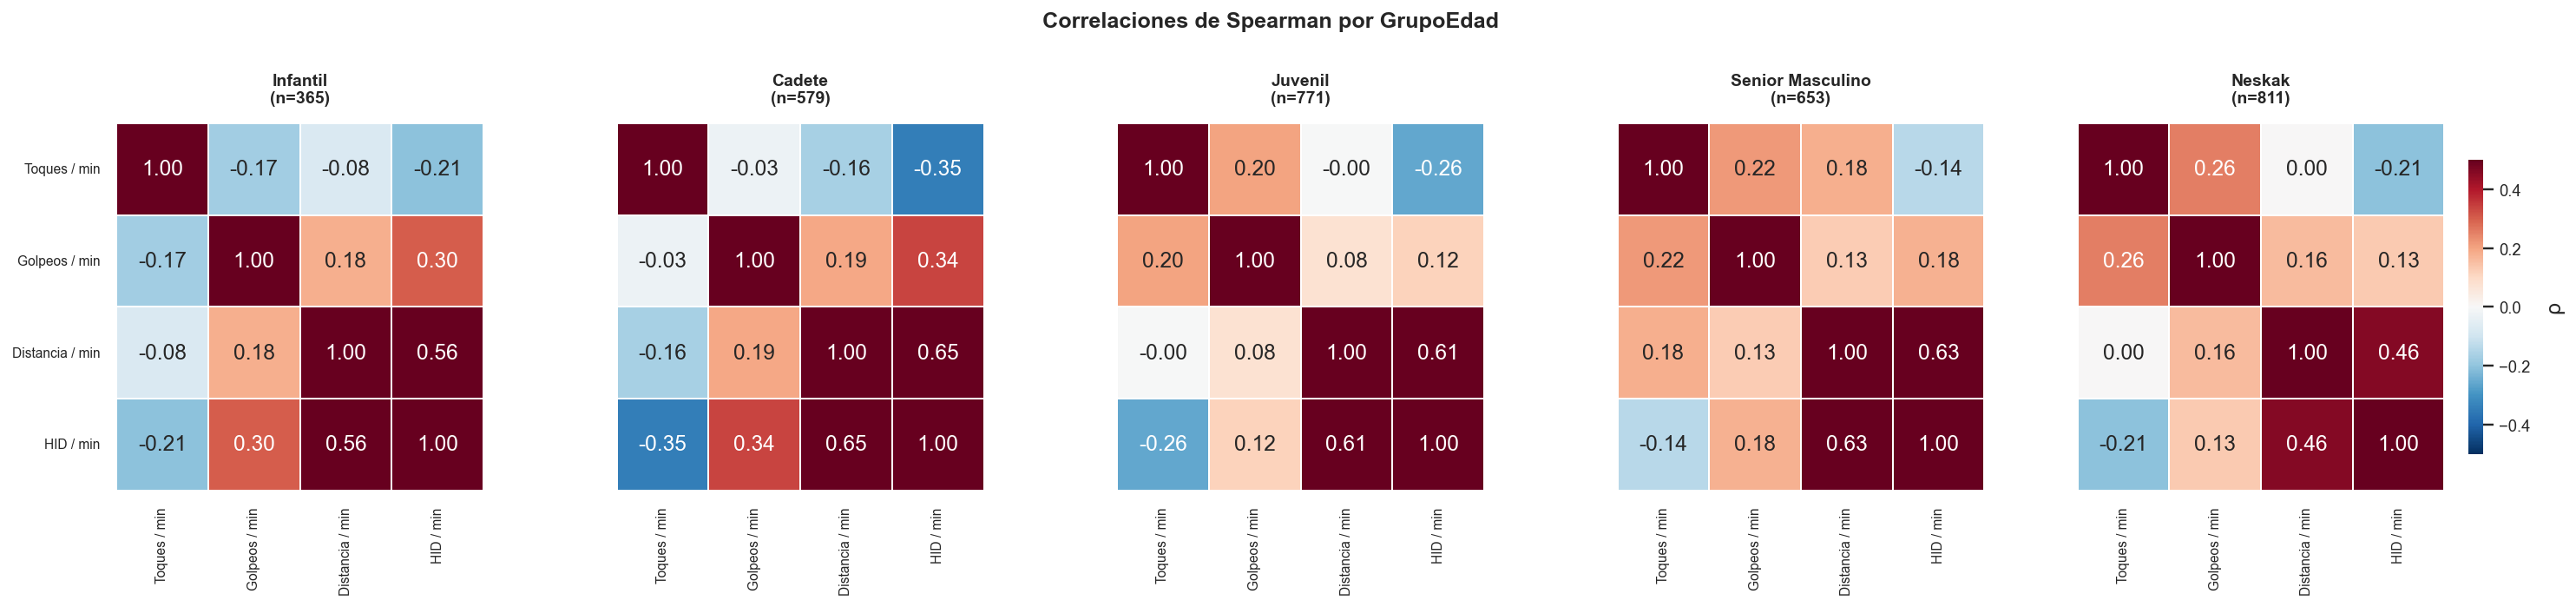

In [12]:
# ── 5 heatmaps Spearman (uno por GrupoEdad) ───────────────
fig, axes = plt.subplots(1, 5, figsize=(22, 4.5))

for idx, grp in enumerate(grupos_edad):
    ax = axes[idx]
    corr_df = corr_por_grupo_s[grp]
    annot_vals = corr_df.values.copy()
    annot_str = np.array([[f"{v:.2f}" for v in row] for row in annot_vals])
    sns.heatmap(
        corr_df, annot=annot_str, fmt="",
        cmap="RdBu_r", center=0, vmin=-0.5, vmax=0.5,
        square=True, linewidths=1, linecolor="white",
        cbar=idx == 4,
        cbar_kws={"shrink": 0.8, "label": "ρ"} if idx == 4 else {},
        ax=ax,
    )
    ax.set_title(f"{grp}\n(n={n_por_grupo[grp]})",
                 fontsize=10, fontweight="bold")
    if idx > 0:
        ax.set_yticklabels([])
        ax.set_ylabel("")
    ax.tick_params(axis="both", labelsize=8)

fig.suptitle("Correlaciones de Spearman por GrupoEdad",
             fontsize=13, fontweight="bold", y=1.05)
plt.tight_layout()
plt.show()

In [13]:
# ── Tabla resumen de correlaciones clave por GrupoEdad ─────
pares_resumen = [
    (0, 2, "Toques × Dist"),
    (0, 3, "Toques × HID"),
    (2, 3, "Dist × HID"),
    (0, 1, "Toques × Golpeos"),
    (1, 3, "Golpeos × HID"),
]

filas_resumen = []
for i, j, par_label in pares_resumen:
    fila = {"Par": par_label}
    for grp in grupos_edad:
        r_p = corr_por_grupo_p[grp].iloc[i, j]
        r_s = corr_por_grupo_s[grp].iloc[i, j]
        fila[f"{grp} (P)"] = f"{r_p:.3f}"
        fila[f"{grp} (S)"] = f"{r_s:.3f}"
    filas_resumen.append(fila)

df_resumen_edad = pd.DataFrame(filas_resumen)

# Mostrar Pearson
cols_pearson = ["Par"] + [f"{g} (P)" for g in grupos_edad]
display(Markdown("### Correlaciones de Pearson por GrupoEdad"))
display(df_resumen_edad[cols_pearson].style.set_caption(
    "r de Pearson para pares clave"
).set_properties(**{"text-align": "center"}))

# Mostrar Spearman
cols_spearman = ["Par"] + [f"{g} (S)" for g in grupos_edad]
display(Markdown("### Correlaciones de Spearman por GrupoEdad"))
display(df_resumen_edad[cols_spearman].style.set_caption(
    "ρ de Spearman para pares clave"
).set_properties(**{"text-align": "center"}))

### Correlaciones de Pearson por GrupoEdad

,Par,Infantil (P),Cadete (P),Juvenil (P),Senior Masculino (P),Neskak (P)
0,Toques × Dist,-0.107,-0.143,-0.035,0.052,-0.049
1,Toques × HID,-0.135,-0.310,-0.260,-0.155,-0.166
2,Dist × HID,0.474,0.597,0.596,0.582,0.362
3,Toques × Golpeos,-0.178,0.066,0.217,0.130,0.169
4,Golpeos × HID,0.242,0.117,0.015,0.021,0.038


### Correlaciones de Spearman por GrupoEdad

,Par,Infantil (S),Cadete (S),Juvenil (S),Senior Masculino (S),Neskak (S)
0,Toques × Dist,-0.076,-0.164,-0.003,0.181,0.004
1,Toques × HID,-0.206,-0.345,-0.259,-0.139,-0.205
2,Dist × HID,0.564,0.646,0.611,0.632,0.458
3,Toques × Golpeos,-0.173,-0.028,0.202,0.218,0.257
4,Golpeos × HID,0.304,0.336,0.117,0.176,0.131


### Interpretación — Correlaciones por GrupoEdad

- **Dist × HID** se mantiene como la correlación más fuerte en todos los grupos (rango: *r* = 0,36 en Neskak a *r* = 0,60 en Cadete/Juvenil), con Spearman aún más alta (ρ = 0,46–0,65).
- **Toques × HID** (trade-off) es consistentemente negativa en todos los grupos (*r* = −0,13 a −0,31), confirmando que el trade-off técnico-físico no es exclusivo de una categoría de edad. La más intensa es en **Cadete** (*r* = −0,31) y **Juvenil** (*r* = −0,26).
- **Toques × Golpeos** es la más variable por GrupoEdad: negativa en **Infantil** (*r* = −0,18) y positiva en **Juvenil** (*r* = 0,22). Esto sugiere que la relación entre volumen técnico y golpeo evoluciona con la maduración deportiva.
- **Golpeos × HID** es relevante en los grupos más jóvenes (Infantil *r* = 0,24; Cadete *r* = 0,12) pero prácticamente nula en Juvenil y Senior (*r* ≈ 0,02).
- La estabilidad del trade-off Toques × HID y la coherencia Dist × HID a través de los 5 grupos confirma que estos patrones son **propiedades del tipo de tarea**, no artefactos de la composición por edad de la muestra.

---
## 5. PCA exploratorio sobre las 4 VD

Un Análisis de Componentes Principales (PCA) permite identificar **dimensiones latentes** del rendimiento. Si las VD se agrupan en ejes interpretables (p.ej., "dimensión física" vs. "dimensión técnica"), esto informará la estrategia de modelización.

In [14]:
# ── Estandarización y PCA ──────────────────────────────────
datos_vd = df[vd_cols].dropna()
scaler = StandardScaler()
X_std = scaler.fit_transform(datos_vd)

pca = PCA(n_components=4)
scores = pca.fit_transform(X_std)

# Varianza explicada
var_exp = pca.explained_variance_ratio_
var_acum = np.cumsum(var_exp)

print("Varianza explicada por componente:")
for i, (ve, va) in enumerate(zip(var_exp, var_acum), 1):
    print(f"  PC{i}: {ve:.3f} ({ve*100:.1f}%)  |  Acumulada: {va:.3f} ({va*100:.1f}%)")

# Cargas factoriales (loadings)
loadings = pd.DataFrame(
    pca.components_.T,
    index=vd_labels,
    columns=[f"PC{i+1}" for i in range(4)]
)
print("\nCargas factoriales (loadings):")
display(loadings.style.format("{:.3f}").background_gradient(
    cmap="RdBu_r", vmin=-1, vmax=1
).set_caption("Loadings de las 4 VD en cada componente principal"))

Varianza explicada por componente:
  PC1: 0.390 (39.0%)  |  Acumulada: 0.390 (39.0%)
  PC2: 0.272 (27.2%)  |  Acumulada: 0.662 (66.2%)
  PC3: 0.216 (21.6%)  |  Acumulada: 0.879 (87.9%)
  PC4: 0.121 (12.1%)  |  Acumulada: 1.000 (100.0%)

Cargas factoriales (loadings):


,PC1,PC2,PC3,PC4
Toques / min,-0.300,0.657,-0.643,0.255
Golpeos / min,0.152,0.742,0.644,-0.110
Distancia / min,0.639,0.133,-0.414,-0.635
HID / min,0.692,-0.001,-0.039,0.721


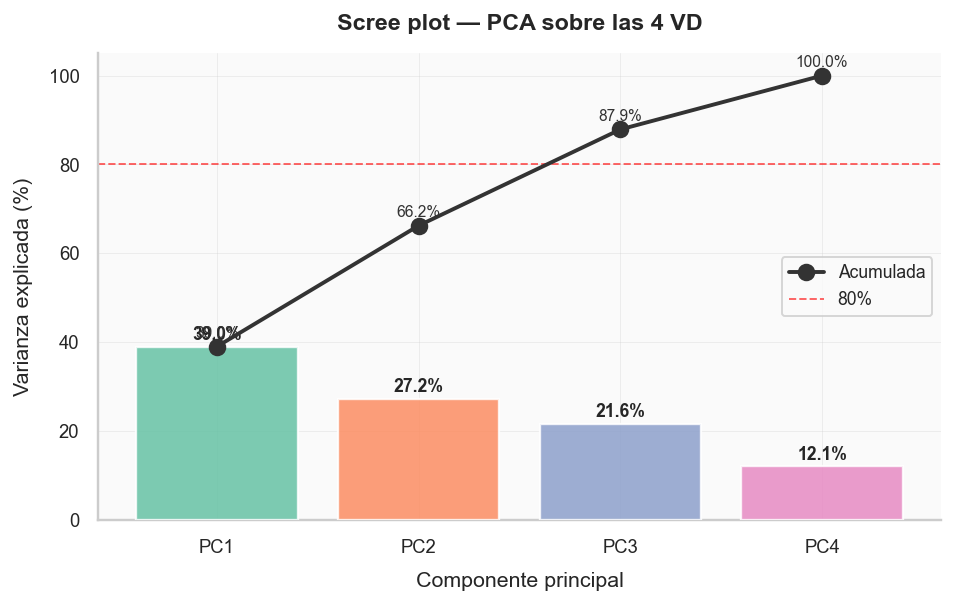

In [15]:
# ── Scree plot ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4.5))

# Barras de varianza individual
bars = ax.bar(
    range(1, 5), var_exp * 100,
    color=colores_vd, edgecolor="white", linewidth=1.2, alpha=0.85,
    zorder=3,
)
# Línea de varianza acumulada
ax.plot(range(1, 5), var_acum * 100, "o-", color="#333333",
        linewidth=2, markersize=8, zorder=4, label="Acumulada")

# Línea del 80%
ax.axhline(80, color="red", linewidth=1, linestyle="--", alpha=0.6, label="80%")

# Anotaciones
for i, (ve, va) in enumerate(zip(var_exp, var_acum)):
    ax.text(i + 1, ve * 100 + 1.5, f"{ve*100:.1f}%", ha="center",
            fontsize=9, fontweight="bold")
    ax.text(i + 1, va * 100 + 2, f"{va*100:.1f}%", ha="center",
            fontsize=8, color="#333333")

ax.set_xlabel("Componente principal", fontsize=11)
ax.set_ylabel("Varianza explicada (%)", fontsize=11)
ax.set_title("Scree plot — PCA sobre las 4 VD", fontsize=12, fontweight="bold")
ax.set_xticks(range(1, 5))
ax.set_xticklabels([f"PC{i}" for i in range(1, 5)])
ax.legend(fontsize=9, loc="center right")
ax.set_ylim(0, 105)
plt.tight_layout()
plt.show()

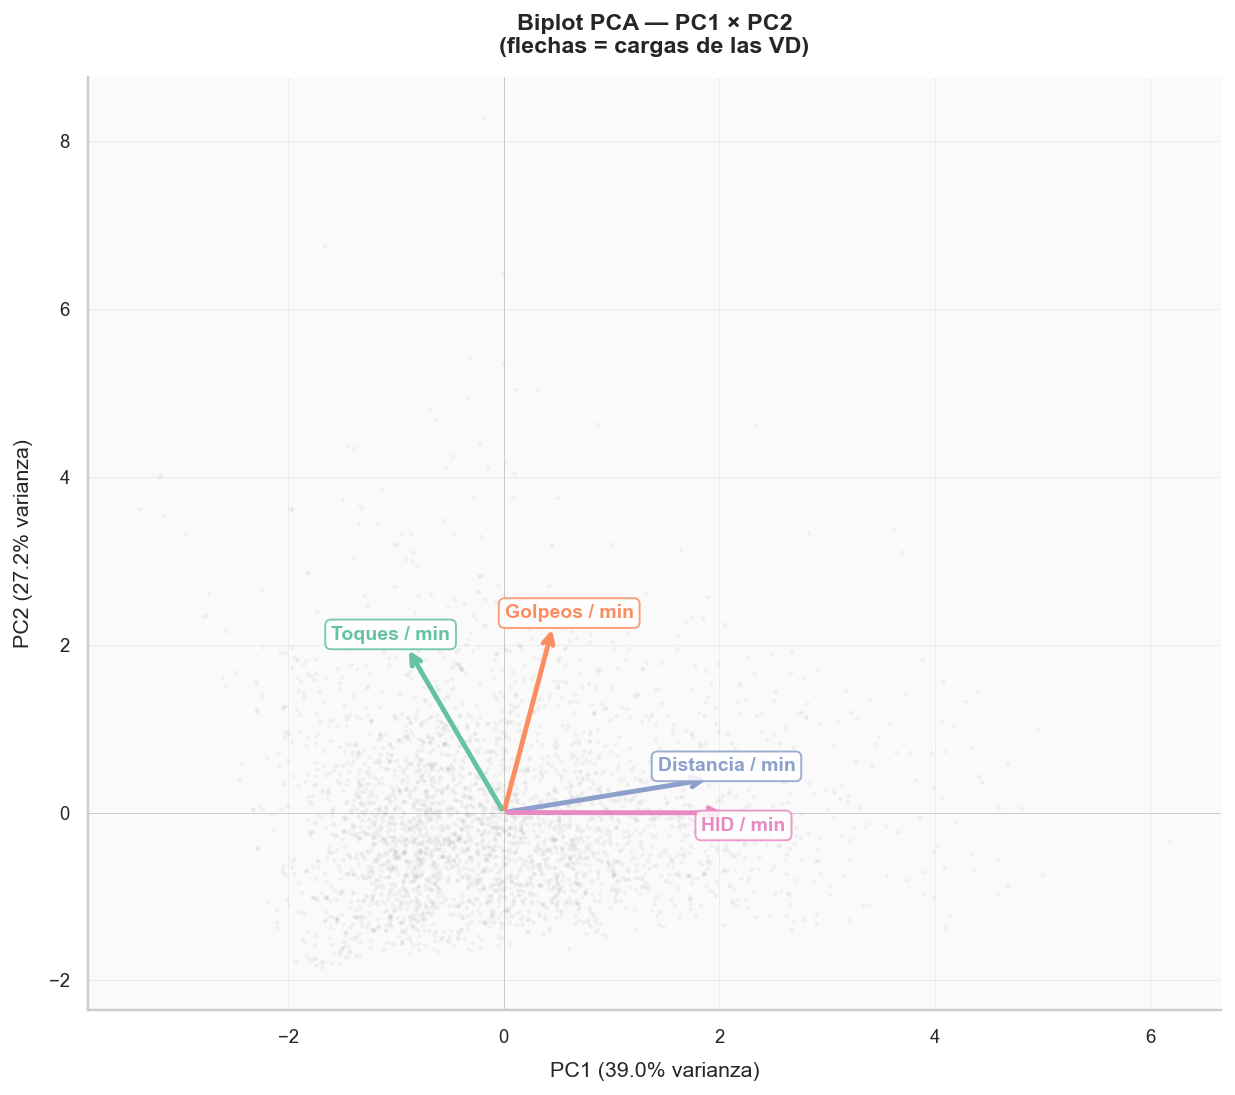

In [16]:
# ── Biplot PC1 × PC2 con flechas de loadings ──────────────
fig, ax = plt.subplots(figsize=(9, 8))

# Proyección de observaciones
ax.scatter(scores[:, 0], scores[:, 1], alpha=0.10, s=5,
           color="#999999", edgecolors="none", rasterized=True)

# Flechas de loadings
scale_arrow = 3.0  # Escalado para visibilidad
for i, label in enumerate(vd_labels):
    ax.annotate(
        "", xy=(loadings.iloc[i, 0] * scale_arrow, loadings.iloc[i, 1] * scale_arrow),
        xytext=(0, 0),
        arrowprops=dict(arrowstyle="->", color=colores_vd[i], lw=2.5),
    )
    # Etiqueta
    offset_x = 0.15 if loadings.iloc[i, 0] >= 0 else -0.15
    offset_y = 0.15 if loadings.iloc[i, 1] >= 0 else -0.15
    ax.text(
        loadings.iloc[i, 0] * scale_arrow + offset_x,
        loadings.iloc[i, 1] * scale_arrow + offset_y,
        label, fontsize=10, fontweight="bold", color=colores_vd[i],
        ha="center", va="center",
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=colores_vd[i], alpha=0.85),
    )

# Ejes de referencia
ax.axhline(0, color="grey", linewidth=0.5, linestyle="-", alpha=0.3)
ax.axvline(0, color="grey", linewidth=0.5, linestyle="-", alpha=0.3)

ax.set_xlabel(f"PC1 ({var_exp[0]*100:.1f}% varianza)", fontsize=11)
ax.set_ylabel(f"PC2 ({var_exp[1]*100:.1f}% varianza)", fontsize=11)
ax.set_title("Biplot PCA — PC1 × PC2\n(flechas = cargas de las VD)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

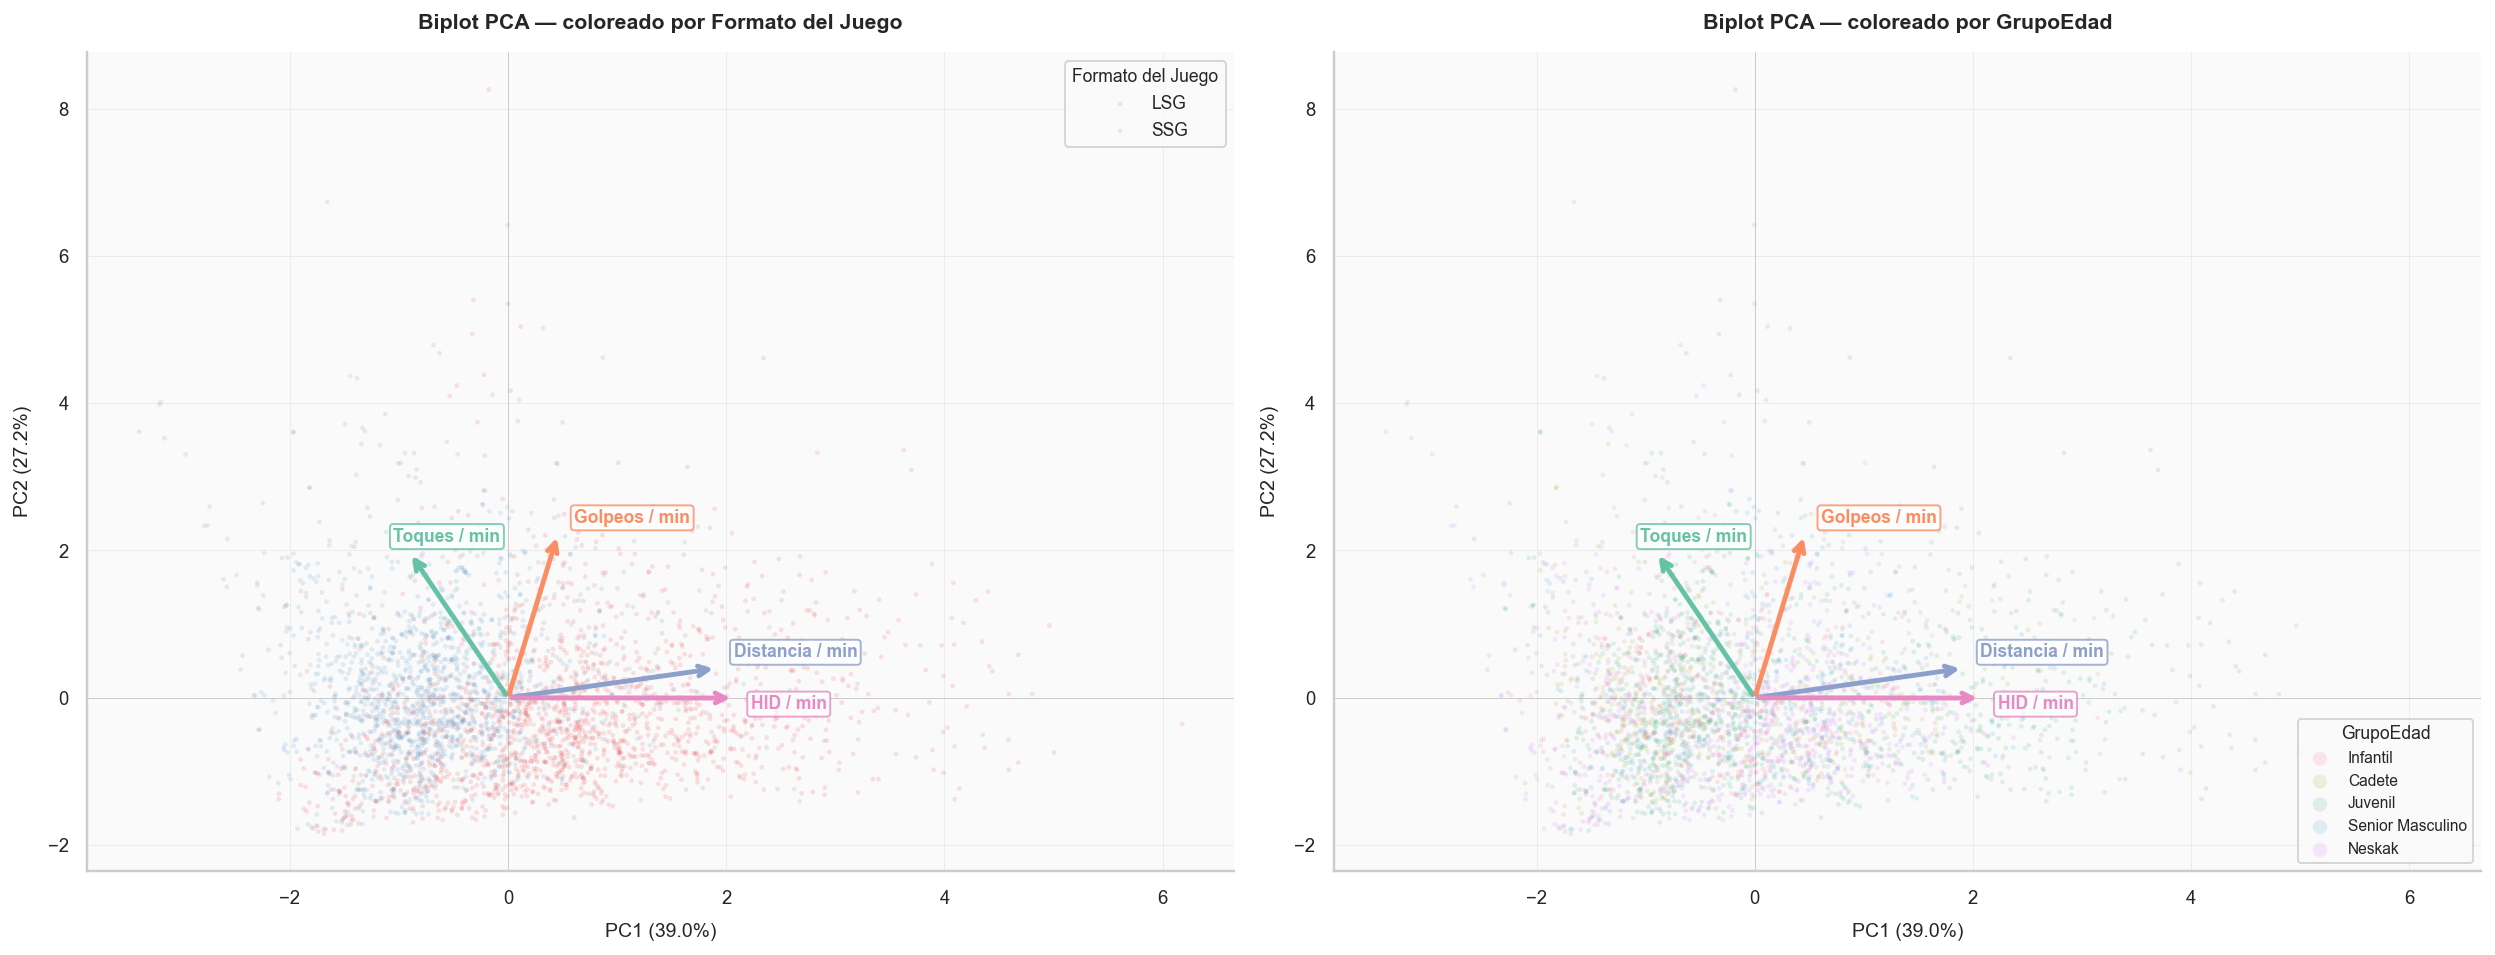

In [17]:
# ── Biplot coloreado por Formato del Juego ─────────────────
idx_valid = datos_vd.index  # Índices sin NaN
formato_valid = df.loc[idx_valid, "Formato_del_Juego"].values

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Panel 1: coloreado por Formato del Juego ---
ax = axes[0]
for nivel, color in colores_formato.items():
    mask = formato_valid == nivel
    ax.scatter(scores[mask, 0], scores[mask, 1], alpha=0.12, s=6,
               color=color, label=nivel, edgecolors="none", rasterized=True)

# Flechas
for i, label in enumerate(vd_labels):
    ax.annotate(
        "", xy=(loadings.iloc[i, 0] * scale_arrow, loadings.iloc[i, 1] * scale_arrow),
        xytext=(0, 0),
        arrowprops=dict(arrowstyle="->", color=colores_vd[i], lw=2.5),
    )
    offset_x = 0.15 if loadings.iloc[i, 0] >= 0 else -0.15
    offset_y = 0.15 if loadings.iloc[i, 1] >= 0 else -0.15
    ax.text(
        loadings.iloc[i, 0] * scale_arrow + offset_x,
        loadings.iloc[i, 1] * scale_arrow + offset_y,
        label, fontsize=9, fontweight="bold", color=colores_vd[i],
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec=colores_vd[i], alpha=0.8),
    )
ax.axhline(0, color="grey", linewidth=0.5, alpha=0.3)
ax.axvline(0, color="grey", linewidth=0.5, alpha=0.3)
ax.set_xlabel(f"PC1 ({var_exp[0]*100:.1f}%)", fontsize=10)
ax.set_ylabel(f"PC2 ({var_exp[1]*100:.1f}%)", fontsize=10)
ax.set_title("Biplot PCA — coloreado por Formato del Juego", fontsize=11, fontweight="bold")
ax.legend(title="Formato del Juego", fontsize=9, title_fontsize=9)

# --- Panel 2: coloreado por GrupoEdad ---
ax = axes[1]
grupo_valid = df.loc[idx_valid, "GrupoEdad"].values
colores_grupo = sns.color_palette("husl", n_colors=len(grupos_edad))
color_map_grupo = dict(zip(grupos_edad, colores_grupo))

for grp in grupos_edad:
    mask = grupo_valid == grp
    ax.scatter(scores[mask, 0], scores[mask, 1], alpha=0.15, s=6,
               color=color_map_grupo[grp], label=grp,
               edgecolors="none", rasterized=True)

# Flechas
for i, label in enumerate(vd_labels):
    ax.annotate(
        "", xy=(loadings.iloc[i, 0] * scale_arrow, loadings.iloc[i, 1] * scale_arrow),
        xytext=(0, 0),
        arrowprops=dict(arrowstyle="->", color=colores_vd[i], lw=2.5),
    )
    offset_x = 0.15 if loadings.iloc[i, 0] >= 0 else -0.15
    offset_y = 0.15 if loadings.iloc[i, 1] >= 0 else -0.15
    ax.text(
        loadings.iloc[i, 0] * scale_arrow + offset_x,
        loadings.iloc[i, 1] * scale_arrow + offset_y,
        label, fontsize=9, fontweight="bold", color=colores_vd[i],
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec=colores_vd[i], alpha=0.8),
    )
ax.axhline(0, color="grey", linewidth=0.5, alpha=0.3)
ax.axvline(0, color="grey", linewidth=0.5, alpha=0.3)
ax.set_xlabel(f"PC1 ({var_exp[0]*100:.1f}%)", fontsize=10)
ax.set_ylabel(f"PC2 ({var_exp[1]*100:.1f}%)", fontsize=10)
ax.set_title("Biplot PCA — coloreado por GrupoEdad", fontsize=11, fontweight="bold")
ax.legend(title="GrupoEdad", fontsize=8, title_fontsize=9,
          loc="lower right", markerscale=3)

plt.tight_layout()
plt.show()

### Interpretación — PCA exploratorio

**Varianza explicada:**
- **PC1** explica el 39,0 %, **PC2** el 27,2 %, **PC3** el 21,6 % y **PC4** el 12,1 %.
- Se necesitan **3 componentes** para superar el 80 % (acumulada = 87,9 %), lo que confirma que las 4 VD no se reducen fácilmente a 1 o 2 dimensiones.

**Interpretación de los ejes:**
- **PC1** (39,0 %) captura un contraste entre las métricas **físicas** (Distancia: +0,64; HID: +0,69) y las **técnicas** (Toques: −0,30). Es el eje del *trade-off* técnico-físico.
- **PC2** (27,2 %) agrupa las métricas técnicas: Toques (+0,66) y Golpeos (+0,74) apuntan hacia arriba, confirmando que el volumen y la potencia técnica covarían en esta dimensión.
- La distribución repartida de varianza (39 % / 27 % / 22 % / 12 %) indica que no hay un factor dominante único: el rendimiento en tareas de entrenamiento es genuinamente **multidimensional**.

**Biplot por tipo de tarea:**
- Las observaciones de formato **LSG** tienden a valores más altos en PC1 (más distancia, más HID), mientras que las de formato **SSG** se concentran en valores negativos de PC1 (más toques).
- Los grupos de edad se superponen ampliamente en el espacio PCA, confirmando que las diferencias principales las marcan las **características de la tarea**, no la edad.

---
## 6. Resumen y conclusiones

## Resumen del análisis de correlaciones

### Estructura de las correlaciones (3 179 observaciones)

| Patrón | Par de VD | Pearson (*r*) | Spearman (ρ) | Interpretación |
|:-------|:----------|:-------------|:-------------|:---------------|
| **Trade-off técnico-físico** | Toques × HID | −0,21*** | −0,24*** | Mayor actividad técnica → menor alta intensidad |
| **Coherencia física** | Dist × HID | 0,48*** | 0,54*** | Las métricas locomotoras covarían positivamente |
| **Independencia parcial técnica** | Toques × Golpeos | 0,09*** | 0,10*** | Volumen y potencia técnica son dimensiones distintas |
| **Independencia técnico-locomotora** | Toques × Dist | −0,05** | ≈ 0,00 ns | Prácticamente nula |
| **Asociación técnico-física débil** | Golpeos × HID | 0,10*** | 0,25*** | Inflada por ceros simultáneos en Pearson |

### Modulación por tipo de tarea

- El **Formato del Juego** (SSG vs. LSG) es el factor que más modifica la estructura correlacional.
- Hallazgo clave: **Toques × Golpeos** pasa de *r* = 0,43*** en LSG a *r* = −0,03 ns en SSG (Fisher *p* < .0001***).
- **Dist × HID** es más fuerte en LSG (*r* = 0,44) que en SSG (*r* = 0,24; Fisher *p* < .0001***).
- **Toques × HID** no cambia entre formatos (*r* ≈ −0,08 en ambos; Fisher *p* = .977 ns): el trade-off es intrínseco.
- Las demás VIs (Polaridad, Equilibrio) tienen efectos moduladores menores.

### Dimensiones latentes (PCA)

- PC1 (39,0 %) captura el contraste físico-técnico; PC2 (27,2 %) agrupa las dos métricas técnicas (Toques y Golpeos).
- Se necesitan **3 componentes** para superar el 80 % de varianza acumulada (87,9 %).
- El espacio PCA refleja claramente la separación por Formato del Juego en PC1.

### Implicaciones para la modelización

1. **Las correlaciones entre VD son moderadas** (max |*r*| = 0,48), lo que justifica analizar cada VD por separado (GLMs independientes) en lugar de un enfoque MANOVA que asumiría una estructura de covarianzas estable.
2. **Las correlaciones cambian por VI** (especialmente por Formato_del_Juego), lo que viola la homogeneidad de covarianzas que asume MANOVA. Esto refuerza la preferencia por GLMs separados.
3. La **inflación de ceros** en Golpeos/min (27,5 %) y HID/min (29,2 %) aconseja considerar modelos que la manejen explícitamente (p.ej., *hurdle models* o *zero-inflated*) en la fase de modelización.
4. El trade-off Toques × HID es una propiedad **intrínseca del diseño de tarea**, no un artefacto de confusión por edad ni de formato.